# Validation Analysis

We first inspect the `core` run on its own, to check whether the framework is working correctly. Then we compare `core` with `interactive` to see whether the extra context features improve prediction or recovery.

In [ ]:
from pathlib import Path
import ast
import csv
import json
import math
import os
import statistics
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "briscola_mpl_cache"))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "artifacts" / "comparison").exists():
            return path
    raise FileNotFoundError("Could not find artifacts/comparison from current path")


ROOT = find_repo_root()
COMPARISON_DIR = ROOT / "artifacts" / "comparison"


def normalize_metric_key(key):
    return key.replace("heldout_", "test_").replace("heldout", "test")


def normalize_metric_row(row):
    return {normalize_metric_key(key): value for key, value in row.items()}


def normalize_metric_rows(rows):
    return [normalize_metric_row(row) for row in rows]


def metric_value(row, key):
    if key in row:
        return row[key]
    legacy_key = key.replace("test_", "heldout_")
    if legacy_key in row:
        return row[legacy_key]
    raise KeyError(key)


def read_csv(path):
    with path.open(newline="", encoding="utf-8") as handle:
        rows = list(csv.DictReader(handle))
    return [coerce_row(row) for row in rows]


def coerce_row(row):
    out = {}
    for raw_key, value in row.items():
        key = normalize_metric_key(raw_key)
        if value is None:
            out[key] = value
            continue
        value = value.strip()
        if key in {"feature_set", "profile", "feature_names", "theta_true", "theta_posterior_mean", "theta_posterior_std", "theta_error", "test_likelihood"}:
            out[key] = value
        elif key in {"runs", "feature_count", "seed", "posterior_samples", "observations", "train_observations", "test_observations"}:
            out[key] = int(float(value))
        else:
            try:
                out[key] = float(value)
            except ValueError:
                out[key] = value
    return out

In [2]:
def fmt(value, digits=3):
    if isinstance(value, float):
        return f"{value:.{digits}f}"
    return str(value)


def make_markdown_table(rows, columns):
    header = "| " + " | ".join(label for label, _ in columns) + " |"
    sep = "| " + " | ".join("---" for _ in columns) + " |"
    body = []
    for row in rows:
        body.append("| " + " | ".join(formatter(row) for _, formatter in columns) + " |")
    return "\n".join([header, sep, *body])


def group_label(row):
    return f"{row['feature_set']} / {row['profile']}"

## Core-Only Run Analysis

This section focuses on the comparison run that uses only the `core` feature set. It summarizes the run-level results, and checks optimization behaviour and theta recovery across profiles and seeds.

In [3]:
CORE_REPORT_PATH = COMPARISON_DIR / "core_main.json"
if not CORE_REPORT_PATH.exists():
    raise FileNotFoundError(CORE_REPORT_PATH)

with CORE_REPORT_PATH.open(encoding="utf-8") as handle:
    core_report = json.load(handle)

core_config = core_report.get("config", {})
core_runs = normalize_metric_rows(core_report["runs"])
core_summary = normalize_metric_rows(core_report["summary"])
core_profiles = [
    profile
    for profile in ["aggressive", "conservative", "greedy_points"]
    if any(row["profile"] == profile for row in core_runs)
]
core_seeds = sorted({row["seed"] for row in core_runs})
core_feature_names = core_runs[0]["feature_names"]

print("Loaded", len(core_summary), "summary rows and", len(core_runs), "run rows")
print("Config:")
for key in ["num_games", "train_fraction", "training_likelihood", "vi_steps", "prior_std", "elbo_samples", "posterior_samples", "seeds"]:
    print(f"  {key}: {core_config.get(key)}")
print("Core run:")
print(f"  report: {CORE_REPORT_PATH.relative_to(ROOT)}")
print(f"  profiles: {core_profiles}")
print(f"  features: {core_feature_names}")

Loaded 3 summary rows and 15 run rows
Config:
  num_games: 150
  train_fraction: 0.75
  training_likelihood: sequential
  vi_steps: 300
  prior_std: 1.0
  elbo_samples: 2
  posterior_samples: 40
  seeds: [0, 1, 2, 3, 4]
Core run:
  report: artifacts/comparison/core_main.json
  profiles: ['aggressive', 'conservative', 'greedy_points']
  features: ['is_trump', 'points_normalized', 'wins_current_trick', 'lowest_card_in_suit']


In [4]:
core_ranked = sorted(core_summary, key=lambda row: metric_value(row, "test_loglik_delta_mean"), reverse=True)
core_table_rows = []
for rank, row in enumerate(core_ranked, start=1):
    core_table_rows.append({
        **row,
        "rank": rank,
        "prob_multiplier": math.exp(metric_value(row, "test_mean_logp_delta_mean")),
    })

core_columns = [
    ("rank", lambda r: str(r["rank"])),
    ("profile", lambda r: r["profile"]),
    ("theta L2 ↓", lambda r: f"{r['theta_l2_error_mean']:.3f} ± {r['theta_l2_error_std']:.3f}"),
    ("test Δ ↑", lambda r: f"{metric_value(r, 'test_loglik_delta_mean'):.2f} ± {metric_value(r, 'test_loglik_delta_std'):.2f}"),
    ("mean logp Δ ↑", lambda r: f"{metric_value(r, 'test_mean_logp_delta_mean'):.4f}"),
    ("prob x ↑", lambda r: f"{r['prob_multiplier']:.3f}x"),
    ("ELBO ↑", lambda r: f"{r['final_elbo_mean']:.1f} ± {r['final_elbo_std']:.1f}"),
    ("runs", lambda r: str(r["runs"])),
]

display(Markdown(make_markdown_table(core_table_rows, core_columns)))

core_best_pred = max(core_summary, key=lambda row: metric_value(row, "test_loglik_delta_mean"))
core_best_recovery = min(core_summary, key=lambda row: row["theta_l2_error_mean"])
core_best_elbo = max(core_summary, key=lambda row: row["final_elbo_mean"])

core_notes = [
    f"**Best test profile:** `{core_best_pred['profile']}` with test Δ `{metric_value(core_best_pred, 'test_loglik_delta_mean'):.2f}`.",
    f"**Best theta recovery:** `{core_best_recovery['profile']}` with theta L2 `{core_best_recovery['theta_l2_error_mean']:.3f}`.",
    f"**Highest final ELBO:** `{core_best_elbo['profile']}` with ELBO `{core_best_elbo['final_elbo_mean']:.1f}`.",
]
display(Markdown("\n\n".join(core_notes)))

| rank | profile | theta L2 ↓ | test Δ ↑ | mean logp Δ ↑ | prob x ↑ | ELBO ↑ | runs |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | conservative | 0.215 ± 0.102 | 58.69 ± 8.03 | 0.0772 | 1.080x | -5404.2 ± 8.2 | 5 |
| 2 | aggressive | 0.269 ± 0.053 | 51.03 ± 6.23 | 0.0671 | 1.069x | -5452.8 ± 3.3 | 5 |
| 3 | greedy_points | 0.423 ± 0.197 | 31.10 ± 5.17 | 0.0409 | 1.042x | -5529.9 ± 12.0 | 5 |

**Best test profile:** `conservative` with test Δ `58.69`.

**Best theta recovery:** `conservative` with theta L2 `0.215`.

**Highest final ELBO:** `conservative` with ELBO `-5404.2`.

### ELBO Optimization

The x-axis shows the progression of VI steps. We plot ELBO minus its value at step 1, so each curve starts near zero and shows how much the objective improves during optimization.

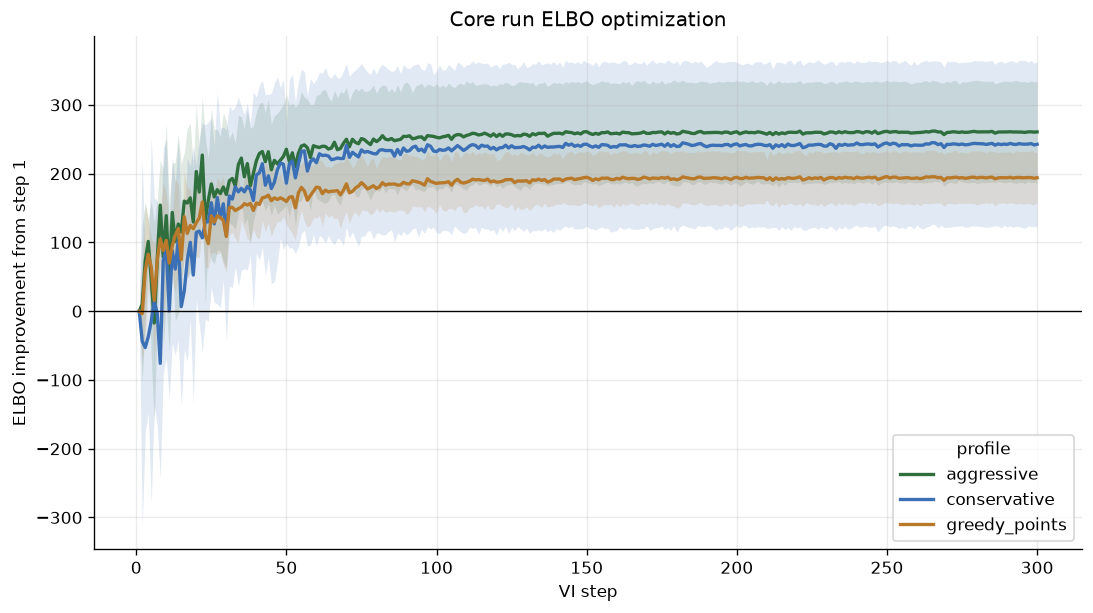

In [5]:
core_palette = {
    "aggressive": "#2f6f3e",
    "conservative": "#3b6fb6",
    "greedy_points": "#b8792b",
}


def core_profile_runs(profile):
    return [row for row in core_runs if row["profile"] == profile]


def elbo_matrix(profile):
    histories = [row["elbo_history"] for row in core_profile_runs(profile)]
    min_len = min(len(history) for history in histories)
    return np.array([history[:min_len] for history in histories], dtype=float)

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)

for profile in core_profiles:
    matrix = elbo_matrix(profile)
    relative = matrix - matrix[:, [0]]
    mean = relative.mean(axis=0)
    std = relative.std(axis=0, ddof=1) if relative.shape[0] > 1 else np.zeros(relative.shape[1])
    steps = np.arange(1, len(mean) + 1)
    color = core_palette.get(profile, "#555555")
    ax.plot(steps, mean, label=profile, color=color, linewidth=2)
    ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Core run ELBO optimization")
ax.set_xlabel("VI step")
ax.set_ylabel("ELBO improvement from step 1")
ax.legend(title="profile")
plt.show()

### Theta Recovery

Each plot compares the true theta with the posterior mean averaged over seeds. Error bars show seed-to-seed variation of the posterior mean.

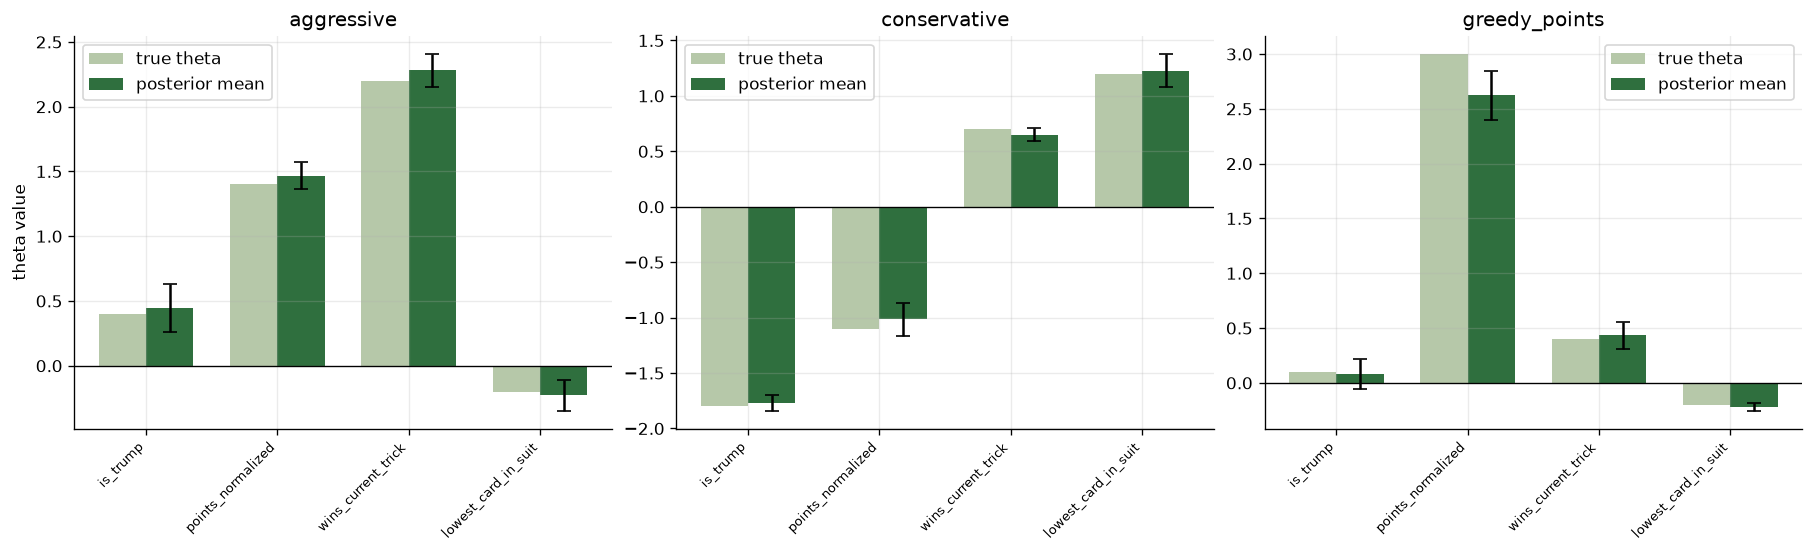

In [6]:
def theta_stats(profile):
    selected = core_profile_runs(profile)
    names = selected[0]["feature_names"]
    true_theta = np.array(selected[0]["theta_true"], dtype=float)
    posterior_means = np.array([row["theta_posterior_mean"] for row in selected], dtype=float)
    mean = posterior_means.mean(axis=0)
    seed_std = posterior_means.std(axis=0, ddof=1) if len(selected) > 1 else np.zeros(len(names))
    return names, true_theta, mean, seed_std

fig, axes = plt.subplots(1, len(core_profiles), figsize=(15, 4.5), constrained_layout=True)
if len(core_profiles) == 1:
    axes = np.array([axes])

for col, profile in enumerate(core_profiles):
    names, true_theta, posterior_mean, seed_std = theta_stats(profile)
    x = np.arange(len(names))

    ax = axes[col]
    ax.bar(x - 0.18, true_theta, width=0.36, label="true theta", color="#b6c8a9")
    ax.bar(
        x + 0.18,
        posterior_mean,
        width=0.36,
        yerr=seed_std,
        capsize=4,
        label="posterior mean",
        color="#2f6f3e",
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(profile)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
    if col == 0:
        ax.set_ylabel("theta value")
    ax.legend(loc="best")

plt.show()

## Core vs Interactive Comparison

This section compares the compact feature set with the richer `interactive` feature set.

In [7]:
SUMMARY_PATH = COMPARISON_DIR / "full_feature_comparison_summary.csv"
RUNS_PATH = COMPARISON_DIR / "full_feature_comparison_runs.csv"
REPORT_PATH = COMPARISON_DIR / "full_feature_comparison.json"

for path in (SUMMARY_PATH, RUNS_PATH, REPORT_PATH):
    if not path.exists():
        raise FileNotFoundError(path)

summary = read_csv(SUMMARY_PATH)
runs = read_csv(RUNS_PATH)
with REPORT_PATH.open(encoding="utf-8") as handle:
    report = json.load(handle)
config = report.get("config", {})
comparison_runs = normalize_metric_rows(report["runs"])

profiles = sorted({row["profile"] for row in summary})
feature_sets = sorted({row["feature_set"] for row in summary})
summary_by_key = {(row["feature_set"], row["profile"]): row for row in summary}
profile_order = [
    profile
    for profile in ["aggressive", "conservative", "greedy_points"]
    if any(row["profile"] == profile for row in summary)
]
feature_order = [
    feature_set
    for feature_set in ["core", "interactive"]
    if any(row["feature_set"] == feature_set for row in summary)
]

print("Loaded", len(summary), "summary rows and", len(runs), "run rows")
print("Config:")
for key in ["num_games", "train_fraction", "training_likelihood", "vi_steps", "prior_std", "elbo_samples", "posterior_samples", "seeds"]:
    print(f"  {key}: {config.get(key)}")

Loaded 6 summary rows and 18 run rows
Config:
  num_games: 100
  train_fraction: 0.75
  training_likelihood: sequential
  vi_steps: 200
  prior_std: 1.0
  elbo_samples: 2
  posterior_samples: 50
  seeds: [0, 1, 2]


### ELBO Optimization

This mirrors the core-only ELBO diagnostic for the full comparison.

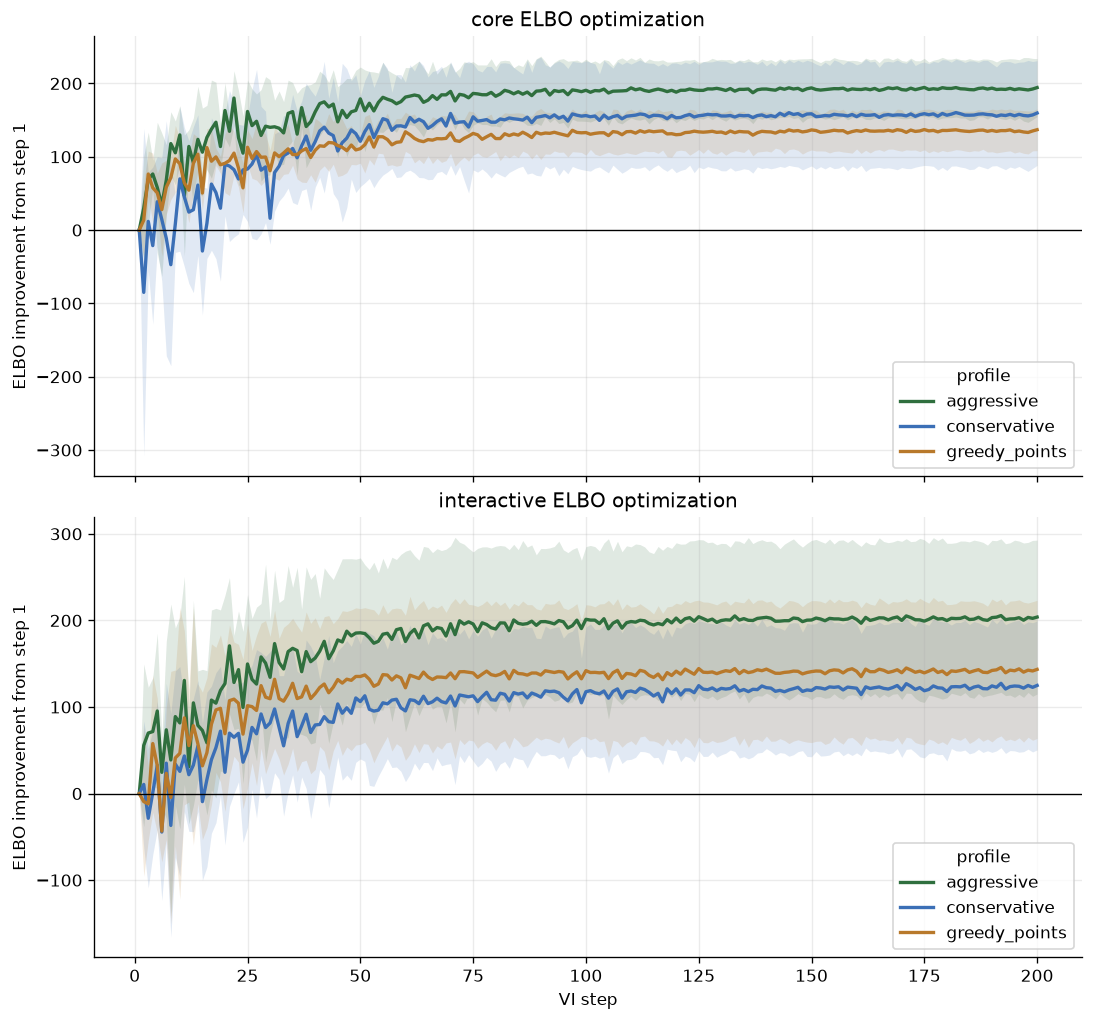

In [8]:
comparison_feature_order = [
    feature_set
    for feature_set in ["core", "interactive"]
    if any(row["feature_set"] == feature_set for row in comparison_runs)
]
comparison_profile_order = [
    profile
    for profile in ["aggressive", "conservative", "greedy_points"]
    if any(row["profile"] == profile for row in comparison_runs)
]
comparison_profile_palette = {
    "aggressive": "#2f6f3e",
    "conservative": "#3b6fb6",
    "greedy_points": "#b8792b",
}


def comparison_elbo_matrix(feature_set, profile):
    histories = [
        row["elbo_history"]
        for row in comparison_runs
        if row["feature_set"] == feature_set and row["profile"] == profile
    ]
    if not histories:
        return None
    min_len = min(len(history) for history in histories)
    return np.array([history[:min_len] for history in histories], dtype=float)

fig, axes = plt.subplots(
    len(comparison_feature_order),
    1,
    figsize=(9, 4.2 * len(comparison_feature_order)),
    sharex=True,
    constrained_layout=True,
)
if len(comparison_feature_order) == 1:
    axes = np.array([axes])

for ax, feature_set in zip(axes, comparison_feature_order):
    for profile in comparison_profile_order:
        matrix = comparison_elbo_matrix(feature_set, profile)
        if matrix is None:
            continue
        relative = matrix - matrix[:, [0]]
        mean = relative.mean(axis=0)
        std = relative.std(axis=0, ddof=1) if relative.shape[0] > 1 else np.zeros(relative.shape[1])
        steps = np.arange(1, len(mean) + 1)
        color = comparison_profile_palette.get(profile, "#555555")
        ax.plot(steps, mean, label=profile, color=color, linewidth=2)
        ax.fill_between(steps, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)

    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"{feature_set} ELBO optimization")
    ax.set_ylabel("ELBO improvement from step 1")
    ax.legend(title="profile", loc="best")

axes[-1].set_xlabel("VI step")
plt.show()

## Performance Summary

The table below is sorted by test improvement. `prob_multiplier` is the geometric per-move probability improvement over the zero-theta baseline: `exp(test_mean_logp_delta_mean)`.

In [9]:
ranked = sorted(summary, key=lambda r: metric_value(r, "test_loglik_delta_mean"), reverse=True)
perf_rows = []
for row in ranked:
    multiplier = math.exp(metric_value(row, "test_mean_logp_delta_mean"))
    perf_rows.append({**row, "config": group_label(row), "prob_multiplier": multiplier})

columns = [
    ("rank", lambda r: str(perf_rows.index(r) + 1)),
    ("config", lambda r: r["config"]),
    ("theta L2 ↓", lambda r: fmt(r["theta_l2_error_mean"], 3)),
    ("test Δ ↑", lambda r: fmt(metric_value(r, "test_loglik_delta_mean"), 2)),
    ("mean logp Δ ↑", lambda r: fmt(metric_value(r, "test_mean_logp_delta_mean"), 4)),
    ("prob x ↑", lambda r: f"{r['prob_multiplier']:.3f}x"),
    ("ELBO ↑", lambda r: fmt(r["final_elbo_mean"], 1)),
    ("runs", lambda r: str(r["runs"])),
]

display(Markdown(make_markdown_table(perf_rows, columns)))

| rank | config | theta L2 ↓ | test Δ ↑ | mean logp Δ ↑ | prob x ↑ | ELBO ↑ | runs |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | core / conservative | 0.314 | 44.39 | 0.0888 | 1.093x | -3608.6 | 3 |
| 2 | interactive / greedy_points | 2.670 | 36.65 | 0.0733 | 1.076x | -3676.2 | 3 |
| 3 | core / aggressive | 0.314 | 31.79 | 0.0636 | 1.066x | -3654.5 | 3 |
| 4 | interactive / aggressive | 1.506 | 27.45 | 0.0549 | 1.056x | -3656.5 | 3 |
| 5 | interactive / conservative | 1.008 | 22.94 | 0.0459 | 1.047x | -3693.5 | 3 |
| 6 | core / greedy_points | 0.612 | 7.70 | 0.0154 | 1.016x | -3708.2 | 3 |

## Quick Read

This cell calls out the best configurations for each objective and the main tradeoff.


In [10]:
best_pred = max(summary, key=lambda r: metric_value(r, "test_loglik_delta_mean"))
best_recovery = min(summary, key=lambda r: r["theta_l2_error_mean"])
best_elbo = max(summary, key=lambda r: r["final_elbo_mean"])
worst_pred = min(summary, key=lambda r: metric_value(r, "test_loglik_delta_mean"))

lines = [
    f"**Best test prediction:** `{group_label(best_pred)}` with test Δ `{metric_value(best_pred, 'test_loglik_delta_mean'):.2f}` and per-move multiplier `{math.exp(metric_value(best_pred, 'test_mean_logp_delta_mean')):.3f}x`.",
    f"**Best theta recovery:** `{group_label(best_recovery)}` with theta L2 `{best_recovery['theta_l2_error_mean']:.3f}`.",
    f"**Best final ELBO:** `{group_label(best_elbo)}` with ELBO `{best_elbo['final_elbo_mean']:.1f}`.",
    f"**Weakest test prediction:** `{group_label(worst_pred)}` with test Δ `{metric_value(worst_pred, 'test_loglik_delta_mean'):.2f}`.",
]

display(Markdown("\n\n".join(lines)))

**Best test prediction:** `core / conservative` with test Δ `44.39` and per-move multiplier `1.093x`.

**Best theta recovery:** `core / aggressive` with theta L2 `0.314`.

**Best final ELBO:** `core / conservative` with ELBO `-3608.6`.

**Weakest test prediction:** `core / greedy_points` with test Δ `7.70`.

## Main Performance Charts

- Left: test predictive improvement versus the zero-theta baseline.
- Right: theta recovery error. Lower is better.

Error bars are the standard deviation across the 3 seeds.


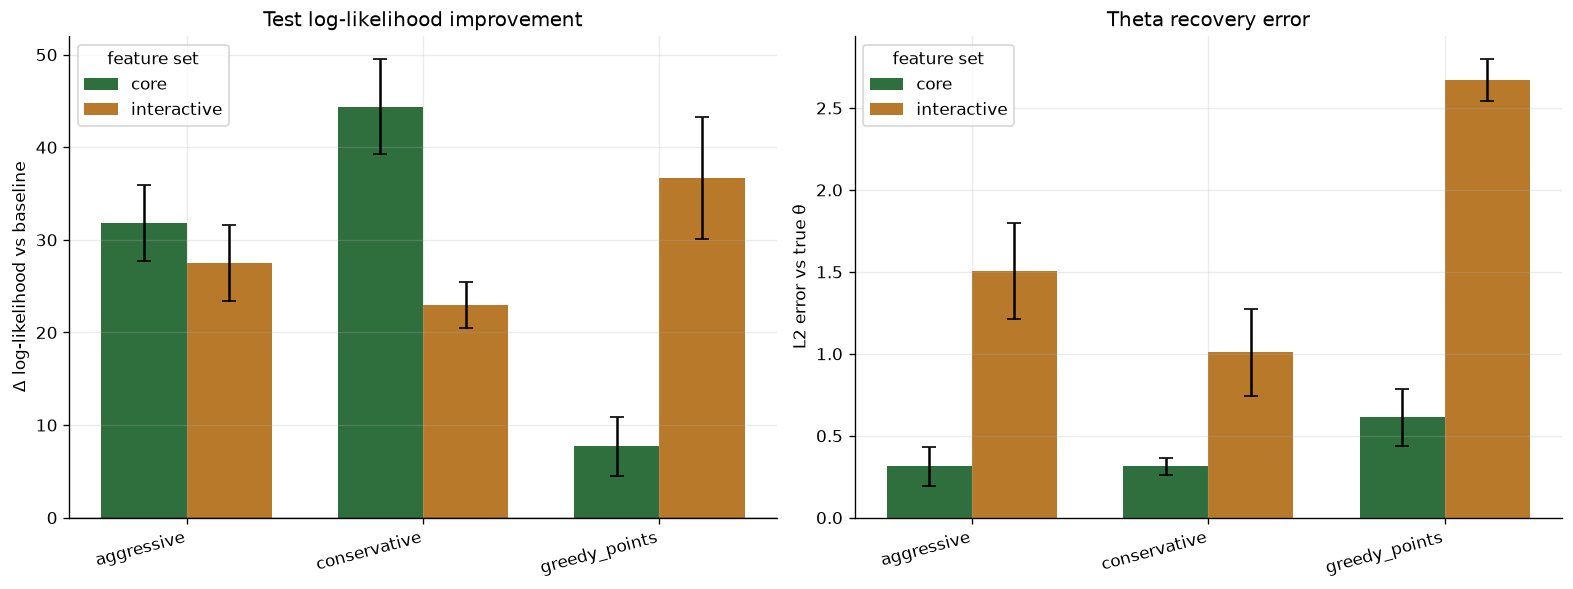

In [11]:
colors = {"core": "#2f6f3e", "interactive": "#b8792b"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
width = 0.36
x = np.arange(len(profile_order))

for i, feature_set in enumerate(feature_order):
    offsets = x + (i - 0.5) * width
    rows = [summary_by_key[(feature_set, profile)] for profile in profile_order]
    test = [metric_value(row, "test_loglik_delta_mean") for row in rows]
    test_std = [metric_value(row, "test_loglik_delta_std") for row in rows]
    theta = [row["theta_l2_error_mean"] for row in rows]
    theta_std = [row["theta_l2_error_std"] for row in rows]

    axes[0].bar(offsets, test, width, yerr=test_std, capsize=4, label=feature_set, color=colors[feature_set])
    axes[1].bar(offsets, theta, width, yerr=theta_std, capsize=4, label=feature_set, color=colors[feature_set])

axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Test log-likelihood improvement")
axes[0].set_ylabel("Δ log-likelihood vs baseline")
axes[0].set_xticks(x)
axes[0].set_xticklabels(profile_order, rotation=15, ha="right")
axes[0].legend(title="feature set")

axes[1].set_title("Theta recovery error")
axes[1].set_ylabel("L2 error vs true θ")
axes[1].set_xticks(x)
axes[1].set_xticklabels(profile_order, rotation=15, ha="right")
axes[1].legend(title="feature set")

plt.show()

## Prediction vs Interpretability Tradeoff

Good configurations should move toward the upper-left: high test improvement and low theta recovery error.


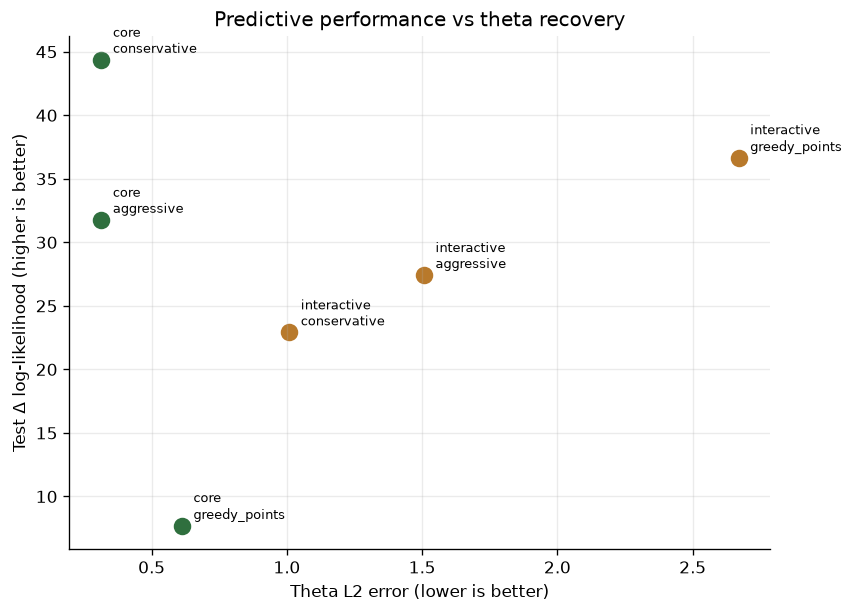

In [12]:
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

for row in summary:
    color = colors.get(row["feature_set"], "#555555")
    ax.scatter(row["theta_l2_error_mean"], metric_value(row, "test_loglik_delta_mean"), s=90, color=color)
    ax.annotate(
        f"{row['feature_set']}\n{row['profile']}",
        (row["theta_l2_error_mean"], metric_value(row, "test_loglik_delta_mean")),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=8,
    )

ax.set_title("Predictive performance vs theta recovery")
ax.set_xlabel("Theta L2 error (lower is better)")
ax.set_ylabel("Test Δ log-likelihood (higher is better)")
plt.show()

## True vs Posterior Mean for Each Configuration


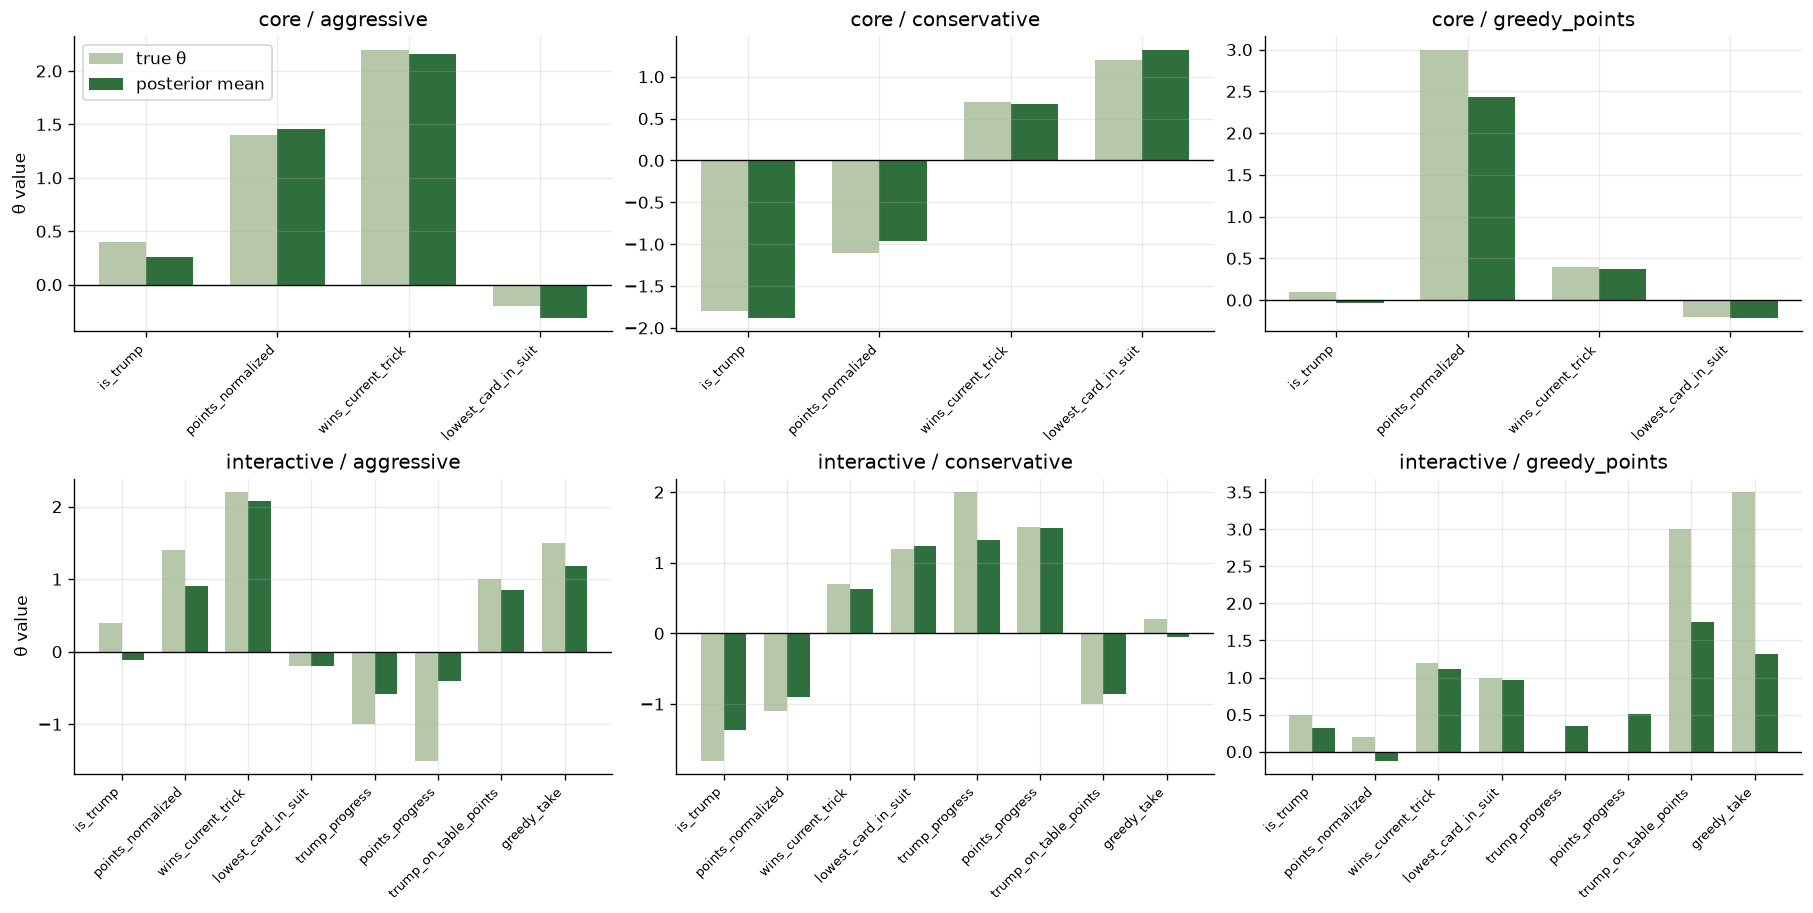

In [13]:
def mean_vector(selected_rows, key):
    vectors = [ast.literal_eval(row[key]) for row in selected_rows]
    return [statistics.fmean(vector[i] for vector in vectors) for i in range(len(vectors[0]))]

fig, axes = plt.subplots(len(feature_order), len(profile_order), figsize=(15, 7.5), constrained_layout=True)

for row_i, feature_set in enumerate(feature_order):
    for col_i, profile in enumerate(profile_order):
        ax = axes[row_i][col_i]
        selected = [row for row in runs if row["feature_set"] == feature_set and row["profile"] == profile]
        names = ast.literal_eval(selected[0]["feature_names"])
        true_theta = ast.literal_eval(selected[0]["theta_true"])
        posterior_mean = mean_vector(selected, "theta_posterior_mean")
        x = np.arange(len(names))
        ax.bar(x - 0.18, true_theta, width=0.36, label="true θ", color="#b6c8a9")
        ax.bar(x + 0.18, posterior_mean, width=0.36, label="posterior mean", color="#2f6f3e")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"{feature_set} / {profile}")
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
        if col_i == 0:
            ax.set_ylabel("θ value")
        if row_i == 0 and col_i == 0:
            ax.legend()

plt.show()